# 05 — Evaluasi
**Resume Classification — Deep Learning Project**

Analisis mendalam performa model terbaik pada test set.

---
**Input  :** `models/final/`, `data/processed/test_dataset.pkl`, `label_encoder.pkl`  
**Output :** grafik evaluasi, classification report, confusion matrix

## 1. Setup & Import Library

In [10]:
import os
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from tqdm import tqdm

PROCESSED_DIR = '../data/processed/'
FINAL_DIR     = '../models/final/'
BATCH_SIZE    = 2

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

# ============================================================
# RESUME DATASET CLASS
# ============================================================
class ResumeDataset(torch.utils.data.Dataset):
    """
    PyTorch Dataset untuk resume classification.
    Kompatibel dengan BERT, DistilBERT, dan Longformer.
    """

    def __init__(self, dataframe, tokenizer, max_length):
        self.texts      = dataframe['clean_text'].tolist() if hasattr(dataframe, 'clean_text') else [item['text'] for item in dataframe]
        self.labels     = dataframe['label'].tolist() if hasattr(dataframe, 'label') else [item['label'] for item in dataframe]
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length      = self.max_length,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt',
        )

        item = {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(label, dtype=torch.long),
        }

        # Longformer butuh global_attention_mask pada token [CLS]
        if 'longformer' in self.tokenizer.name_or_path.lower():
            global_attention_mask = torch.zeros_like(item['input_ids'])
            global_attention_mask[0] = 1   # aktifkan global attention di [CLS]
            item['global_attention_mask'] = global_attention_mask

        return item

Device : cuda


## 2. Load Model, Label Encoder & Test Dataset

In [11]:
# Load model terbaik (auto-detect architecture)
model = AutoModelForSequenceClassification.from_pretrained(FINAL_DIR)
model = model.to(DEVICE)
model.eval()
print('Model loaded dari:', FINAL_DIR)

# Load label encoder
with open(os.path.join(FINAL_DIR, 'label_encoder.pkl'), 'rb') as f:
    le = pickle.load(f)

# Label pendek untuk tampilan grafik
SHORT_LABELS = [
    'BI / BO', 'Business Analyst', 'DWH / ETL',
    'Java Dev', 'Network SysAdmin', 'Project Manager',
    'Recruiter', 'SQL Dev', 'Web Dev'
]

print(f'Kelas : {le.classes_.tolist()}')

# Load test dataset
with open(os.path.join(PROCESSED_DIR, 'test_dataset.pkl'), 'rb') as f:
    test_dataset = pickle.load(f)

print(f'Test  : {len(test_dataset):,} sampel')

# Load training config
with open(os.path.join(FINAL_DIR, 'train_config.json'), 'r') as f:
    train_config = json.load(f)

print(f"\nBest epoch training : {train_config['best_epoch']}")
print(f"Best val F1         : {train_config['best_val_f1']:.4f}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6575.04it/s]


Model loaded dari: ../models/final/
Kelas : ['Business Analyst (BA) Resumes', 'Business Intelligence, Business Object Resumes', 'Datawarehousing, ETL, Informatica Resumes', 'Java Developers/Architects Resumes', 'Network and Systems Administrators Resumes', 'Project Manager Resumes', 'Recruiter Resumes', 'SQL Developers Resumes', 'Web Developer Resumes']
Test  : 862 sampel

Best epoch training : 5
Best val F1         : 0.8449


In [12]:
test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = True,
)
print(f'Test batches : {len(test_loader)}')

Test batches : 431


## 3. Inference pada Test Set

In [16]:
all_preds  = []
all_labels = []
all_probs  = []   # untuk analisis confidence

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Inference test set'):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        outputs = model(
            input_ids      = input_ids,
            attention_mask = attention_mask,
        )
        logits  = outputs.logits
        probs   = torch.softmax(logits, dim=1)
        preds   = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print('Inference selesai!')
print(f'Total sampel : {len(all_preds)}')

Inference test set: 100%|██████████| 431/431 [00:32<00:00, 13.41it/s]

Inference selesai!
Total sampel : 862


## 4. Metrik Utama

In [17]:
accuracy   = accuracy_score(all_labels, all_preds)
macro_f1   = f1_score(all_labels, all_preds, average='macro')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

print('HASIL EVALUASI — TEST SET')
print(f'  Accuracy       : {accuracy*100:.2f}%')
print(f'  Macro F1       : {macro_f1:.4f}')
print(f'  Weighted F1    : {weighted_f1:.4f}')

HASIL EVALUASI — TEST SET
  Accuracy       : 84.34%
  Macro F1       : 0.8256
  Weighted F1    : 0.8418


## 5. Classification Report per Kelas

In [18]:
report = classification_report(
    all_labels,
    all_preds,
    target_names = SHORT_LABELS,
    digits       = 4,
)
print(report)

# Simpan ke file teks
report_path = os.path.join(FINAL_DIR, 'classification_report.txt')
with open(report_path, 'w') as f:
    f.write(report)
print(f'Report disimpan ke: {report_path}')

                  precision    recall  f1-score   support

         BI / BO     0.9367    0.8506    0.8916        87
Business Analyst     0.8738    0.8411    0.8571       107
       DWH / ETL     0.8657    0.8722    0.8689       133
        Java Dev     0.7671    0.8358    0.8000        67
Network SysAdmin     0.7364    0.8020    0.7678       101
 Project Manager     0.8899    0.9798    0.9327        99
       Recruiter     0.6667    0.5200    0.5843        50
         SQL Dev     0.8571    0.8036    0.8295       112
         Web Dev     0.8818    0.9151    0.8981       106

        accuracy                         0.8434       862
       macro avg     0.8306    0.8245    0.8256       862
    weighted avg     0.8432    0.8434    0.8418       862

Report disimpan ke: ../models/final/classification_report.txt


## 6. Confusion Matrix

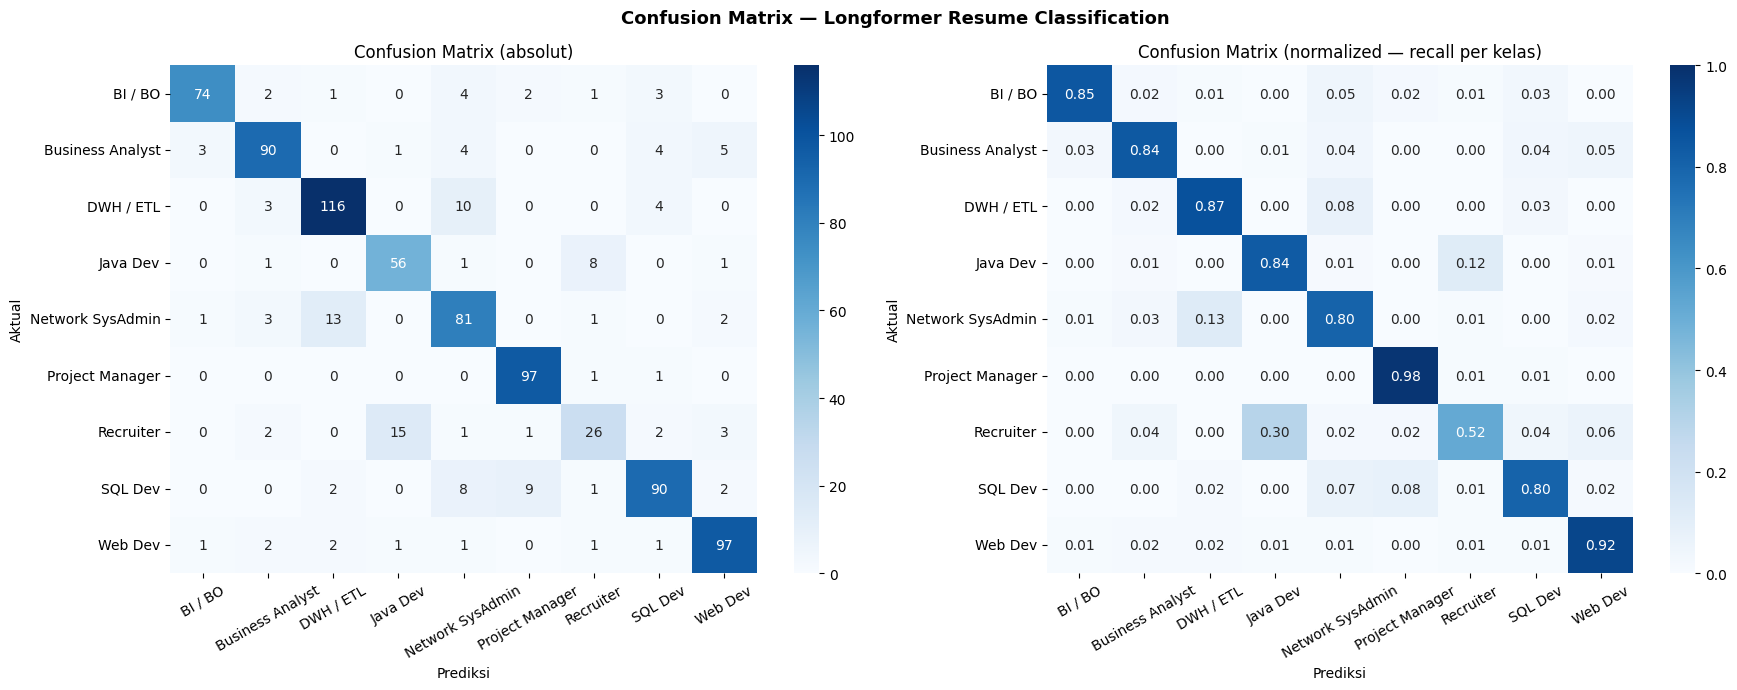

Grafik disimpan ke: data/evaluation_confusion_matrix.png


In [19]:
cm = confusion_matrix(all_labels, all_preds)

# Confusion matrix absolut
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    cm,
    annot        = True,
    fmt          = 'd',
    cmap         = 'Blues',
    xticklabels  = SHORT_LABELS,
    yticklabels  = SHORT_LABELS,
    ax           = axes[0],
)
axes[0].set_title('Confusion Matrix (absolut)')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# Confusion matrix dinormalisasi (per baris = recall per kelas)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm,
    annot        = True,
    fmt          = '.2f',
    cmap         = 'Blues',
    xticklabels  = SHORT_LABELS,
    yticklabels  = SHORT_LABELS,
    vmin         = 0,
    vmax         = 1,
    ax           = axes[1],
)
axes[1].set_title('Confusion Matrix (normalized — recall per kelas)')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Confusion Matrix — Longformer Resume Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/evaluation_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan ke: data/evaluation_confusion_matrix.png')

## 7. F1 Score per Kelas

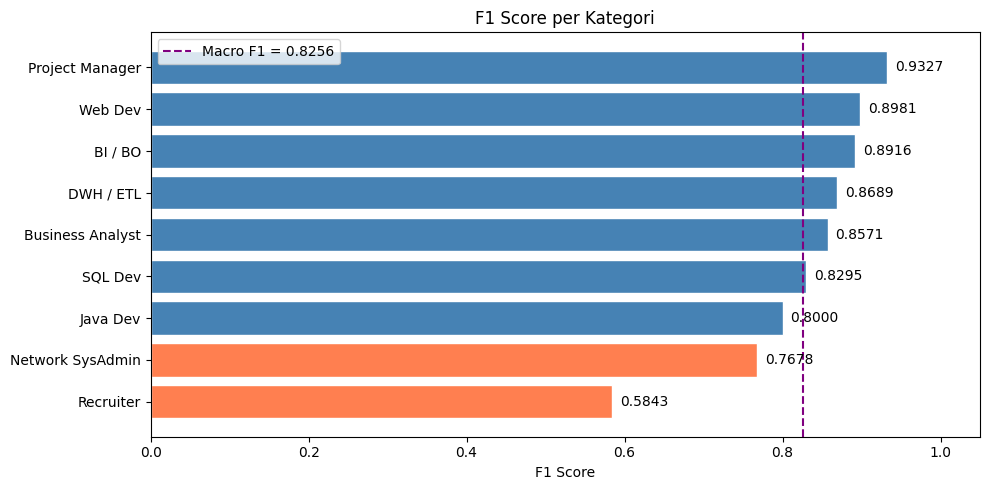

⚠ Kelas dengan F1 < 0.80 (perlu perhatian):
        kategori  f1_score
       Recruiter  0.584270
Network SysAdmin  0.767773


In [20]:
f1_per_class = f1_score(all_labels, all_preds, average=None)

f1_df = pd.DataFrame({
    'kategori' : SHORT_LABELS,
    'f1_score' : f1_per_class,
}).sort_values('f1_score')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['coral' if v < 0.80 else 'steelblue' for v in f1_df['f1_score']]
bars = ax.barh(f1_df['kategori'], f1_df['f1_score'], color=colors, edgecolor='white')
ax.axvline(macro_f1, color='purple', linestyle='--', label=f'Macro F1 = {macro_f1:.4f}')
ax.set_xlim(0, 1.05)
ax.set_xlabel('F1 Score')
ax.set_title('F1 Score per Kategori')
ax.legend()
for bar, val in zip(bars, f1_df['f1_score']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/evaluation_f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

# Highlight kelas yang perlu perhatian
weak_classes = f1_df[f1_df['f1_score'] < 0.80]
if len(weak_classes) > 0:
    print('⚠ Kelas dengan F1 < 0.80 (perlu perhatian):')
    print(weak_classes.to_string(index=False))
else:
    print('✓ Semua kelas memiliki F1 >= 0.80')

## 8. Analisis Confidence Model

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5576\996357066.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(SHORT_LABELS, rotation=30, ha='right')


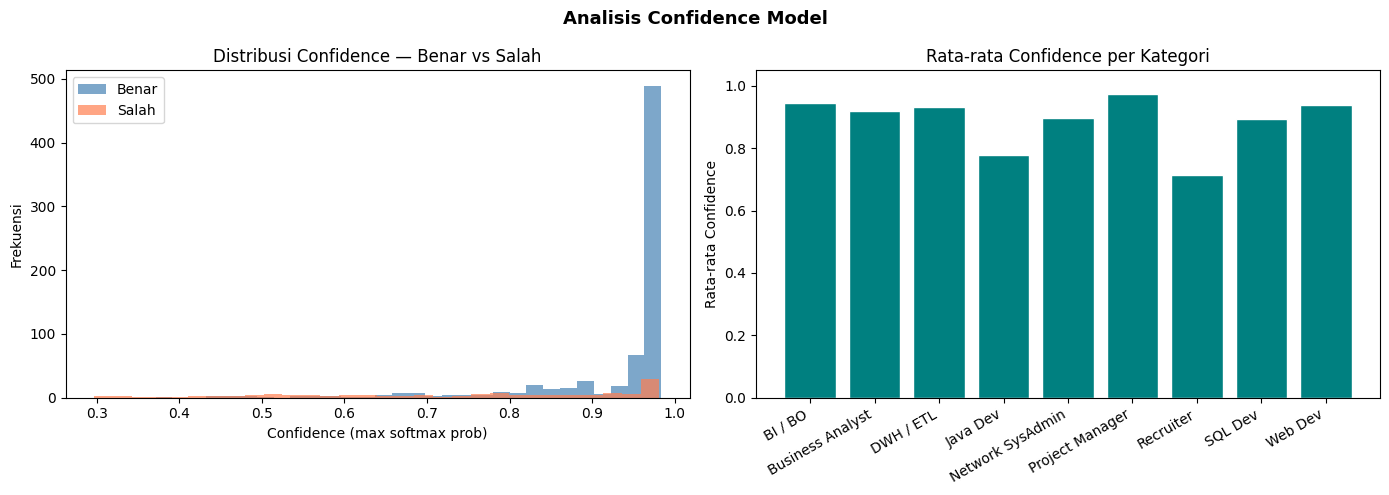

Rata-rata confidence (prediksi benar) : 0.9324
Rata-rata confidence (prediksi salah) : 0.7507


In [21]:
# Confidence = probabilitas tertinggi dari prediksi
confidence     = all_probs.max(axis=1)
is_correct     = (all_preds == all_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi confidence
axes[0].hist(confidence[is_correct],  bins=30, alpha=0.7, color='steelblue', label='Benar')
axes[0].hist(confidence[~is_correct], bins=30, alpha=0.7, color='coral',     label='Salah')
axes[0].set_xlabel('Confidence (max softmax prob)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Confidence — Benar vs Salah')
axes[0].legend()

# Rata-rata confidence per kelas
avg_conf_per_class = [
    confidence[all_labels == i].mean()
    for i in range(len(SHORT_LABELS))
]
axes[1].bar(SHORT_LABELS, avg_conf_per_class, color='teal', edgecolor='white')
axes[1].set_xticklabels(SHORT_LABELS, rotation=30, ha='right')
axes[1].set_ylabel('Rata-rata Confidence')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Rata-rata Confidence per Kategori')

plt.suptitle('Analisis Confidence Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/evaluation_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Rata-rata confidence (prediksi benar) : {confidence[is_correct].mean():.4f}')
print(f'Rata-rata confidence (prediksi salah) : {confidence[~is_correct].mean():.4f}')

## 9. Contoh Prediksi Salah

In [22]:
# Load test dataframe untuk ambil teks asli
test_df = pd.read_pickle(os.path.join(PROCESSED_DIR, 'test.pkl'))

# Tambahkan hasil prediksi
test_df['pred_label']    = all_preds
test_df['true_label']    = all_labels
test_df['confidence']    = confidence
test_df['is_correct']    = is_correct
test_df['pred_category'] = le.inverse_transform(all_preds)

# Tampilkan 5 contoh prediksi salah dengan confidence tinggi
wrong_df = test_df[~test_df['is_correct']].sort_values('confidence', ascending=False)

print(f'Total prediksi salah : {len(wrong_df)} dari {len(test_df)} ({len(wrong_df)/len(test_df)*100:.1f}%)')
print()
print('5 Prediksi salah dengan confidence tertinggi (model paling yakin tapi salah):')
print()

for i, row in wrong_df.head(5).iterrows():
    print(f'  Aktual    : {row["category"]}')
    print(f'  Prediksi  : {row["pred_category"]}')
    print(f'  Confidence: {row["confidence"]:.4f}')
    print(f'  Teks      : {row["clean_text"][:200]}...')
    print()

Total prediksi salah : 135 dari 862 (15.7%)

5 Prediksi salah dengan confidence tertinggi (model paling yakin tapi salah):

  Aktual    : Business Analyst (BA) Resumes
  Prediksi  : Project Manager Resumes
  Confidence: 0.9816
  Teks      : Total years of experience in IT industry and years of professional experience in software development on SAP R ABAP programming and year of QA experience Having years experience as SAP R ABAP Programm...

  Aktual    : SQL Developers Resumes
  Prediksi  : Project Manager Resumes
  Confidence: 0.9808
  Teks      : I am a seasoned IT professional with extensive IT management experience I held various roles throughout my career in both technical and managerial capacities including Developer Systems Analyst Busine...

  Aktual    : Business Intelligence, Business Object Resumes
  Prediksi  : Business Analyst (BA) Resumes
  Confidence: 0.9794
  Teks      : Eight years of experience in software Analysis Design and Software Quality Assurance Testing Manual

## 10. Ringkasan Evaluasi

In [23]:
print('=' * 60)
print('RINGKASAN EVALUASI — TEST SET')
print('=' * 60)
print(f"""
METRIK UTAMA
  Accuracy     : {accuracy*100:.2f}%
  Macro F1     : {macro_f1:.4f}
  Weighted F1  : {weighted_f1:.4f}

KELAS TERBAIK
  {f1_df.iloc[-1]['kategori']:20s} F1 = {f1_df.iloc[-1]['f1_score']:.4f}

KELAS TERLEMAH
  {f1_df.iloc[0]['kategori']:20s} F1 = {f1_df.iloc[0]['f1_score']:.4f}

CONFIDENCE
  Rata-rata (benar) : {confidence[is_correct].mean():.4f}
  Rata-rata (salah) : {confidence[~is_correct].mean():.4f}

OUTPUT
  data/evaluation_confusion_matrix.png
  data/evaluation_f1_per_class.png
  data/evaluation_confidence.png
  models/final/classification_report.txt
""")
print('=' * 60)
print('Lanjut ke: 06_inference.ipynb')

RINGKASAN EVALUASI — TEST SET

METRIK UTAMA
  Accuracy     : 84.34%
  Macro F1     : 0.8256
  Weighted F1  : 0.8418

KELAS TERBAIK
  Project Manager      F1 = 0.9327

KELAS TERLEMAH
  Recruiter            F1 = 0.5843

CONFIDENCE
  Rata-rata (benar) : 0.9324
  Rata-rata (salah) : 0.7507

OUTPUT
  data/evaluation_confusion_matrix.png
  data/evaluation_f1_per_class.png
  data/evaluation_confidence.png
  models/final/classification_report.txt

Lanjut ke: 06_inference.ipynb


---
**Notebook ini selesai.** Lanjut ke `06_inference.ipynb` untuk membungkus model menjadi API yang siap dipakai website.